In [14]:
from representation_analysis import compute_dead_neurons, bootstrap_ci, compute_sparsity_per_episode
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


In [8]:
# Mock data: 3 runs, 5 episodes each, 10 timesteps, 20 FTA units
np.random.seed(0)

runs_out_arrays = []
for run in range(3):
    run_data = []
    for ep in range(5):
        # Each episode: 10 timesteps, 20 units
        # Make some units always dead (< 0.1) to test
        ep_data = []
        for t in range(10):
            output = np.ones(20)
            output[:5] = 0.0  # first 5 units always dead
            ep_data.append(output)
        run_data.append(ep_data)
    runs_out_arrays.append(run_data)

# Test
means, lows, highs = compute_dead_neurons(runs_out_arrays, thres=0.1)

print(f"Shape of means: {means.shape}")  # should be (5,) one per episode
print(f"Means: {means}")                 # should be ~25% (5 out of 20 units dead)
print(f"CI low: {lows}")
print(f"CI high: {highs}")

Shape of means: (5,)
Means: [25. 25. 25. 25. 25.]
CI low: [25. 25. 25. 25. 25.]
CI high: [25. 25. 25. 25. 25.]


In [9]:
# Mock data: 3 runs, 5 episodes each, 10 timesteps, 20 FTA units
np.random.seed(0)

runs_out_arrays = []
for run in range(3):
    run_data = []
    for ep in range(5):
        ep_data = []
        for t in range(10):
            output = np.ones(20)
            output[:10] = 0.05  # first 10 units always inactive (< 0.1)
            ep_data.append(output)
        run_data.append(ep_data)
    runs_out_arrays.append(run_data)

means, lows, highs = compute_sparsity_per_episode(runs_out_arrays, thres=0.1)

print(f"Shape of means: {means.shape}")  # should be (5,) one per episode
print(f"Means: {means}")                 # should be ~50% (10 out of 20 units inactive)
print(f"CI low: {lows}")
print(f"CI high: {highs}")

# Sanity check: means should be close to 50%
assert all(45 < m < 55 for m in means), "Expected ~50% dead neurons"
print("\nSanity check passed!")

Shape of means: (5,)
Means: [50. 50. 50. 50. 50.]
CI low: [50. 50. 50. 50. 50.]
CI high: [50. 50. 50. 50. 50.]

Sanity check passed!


In [16]:
out_array = pickle.load(open(os.path.join("data", "Double_ReLU_220_units/env_walls/seed_0/all_out_arrays_seed_0"), "rb"))
states = pickle.load(open(os.path.join("data", "Double_ReLU_220_units/env_walls/seed_0/all_episodes_states_seed_0"), "rb"))

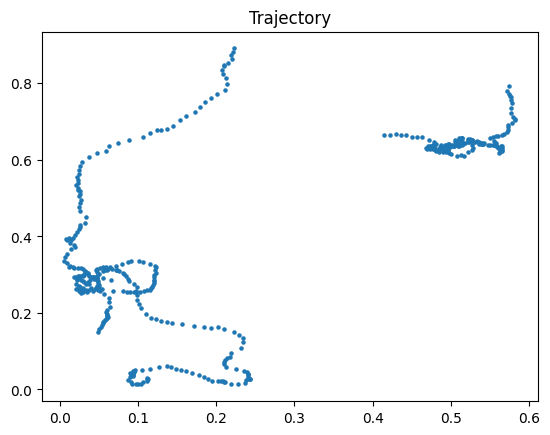

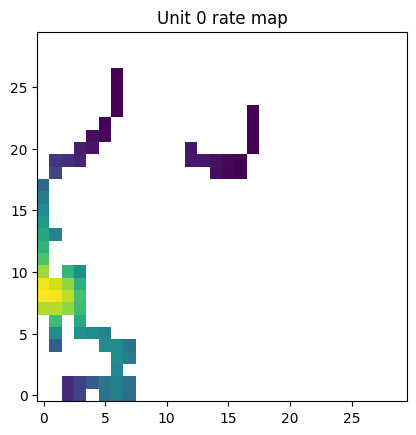

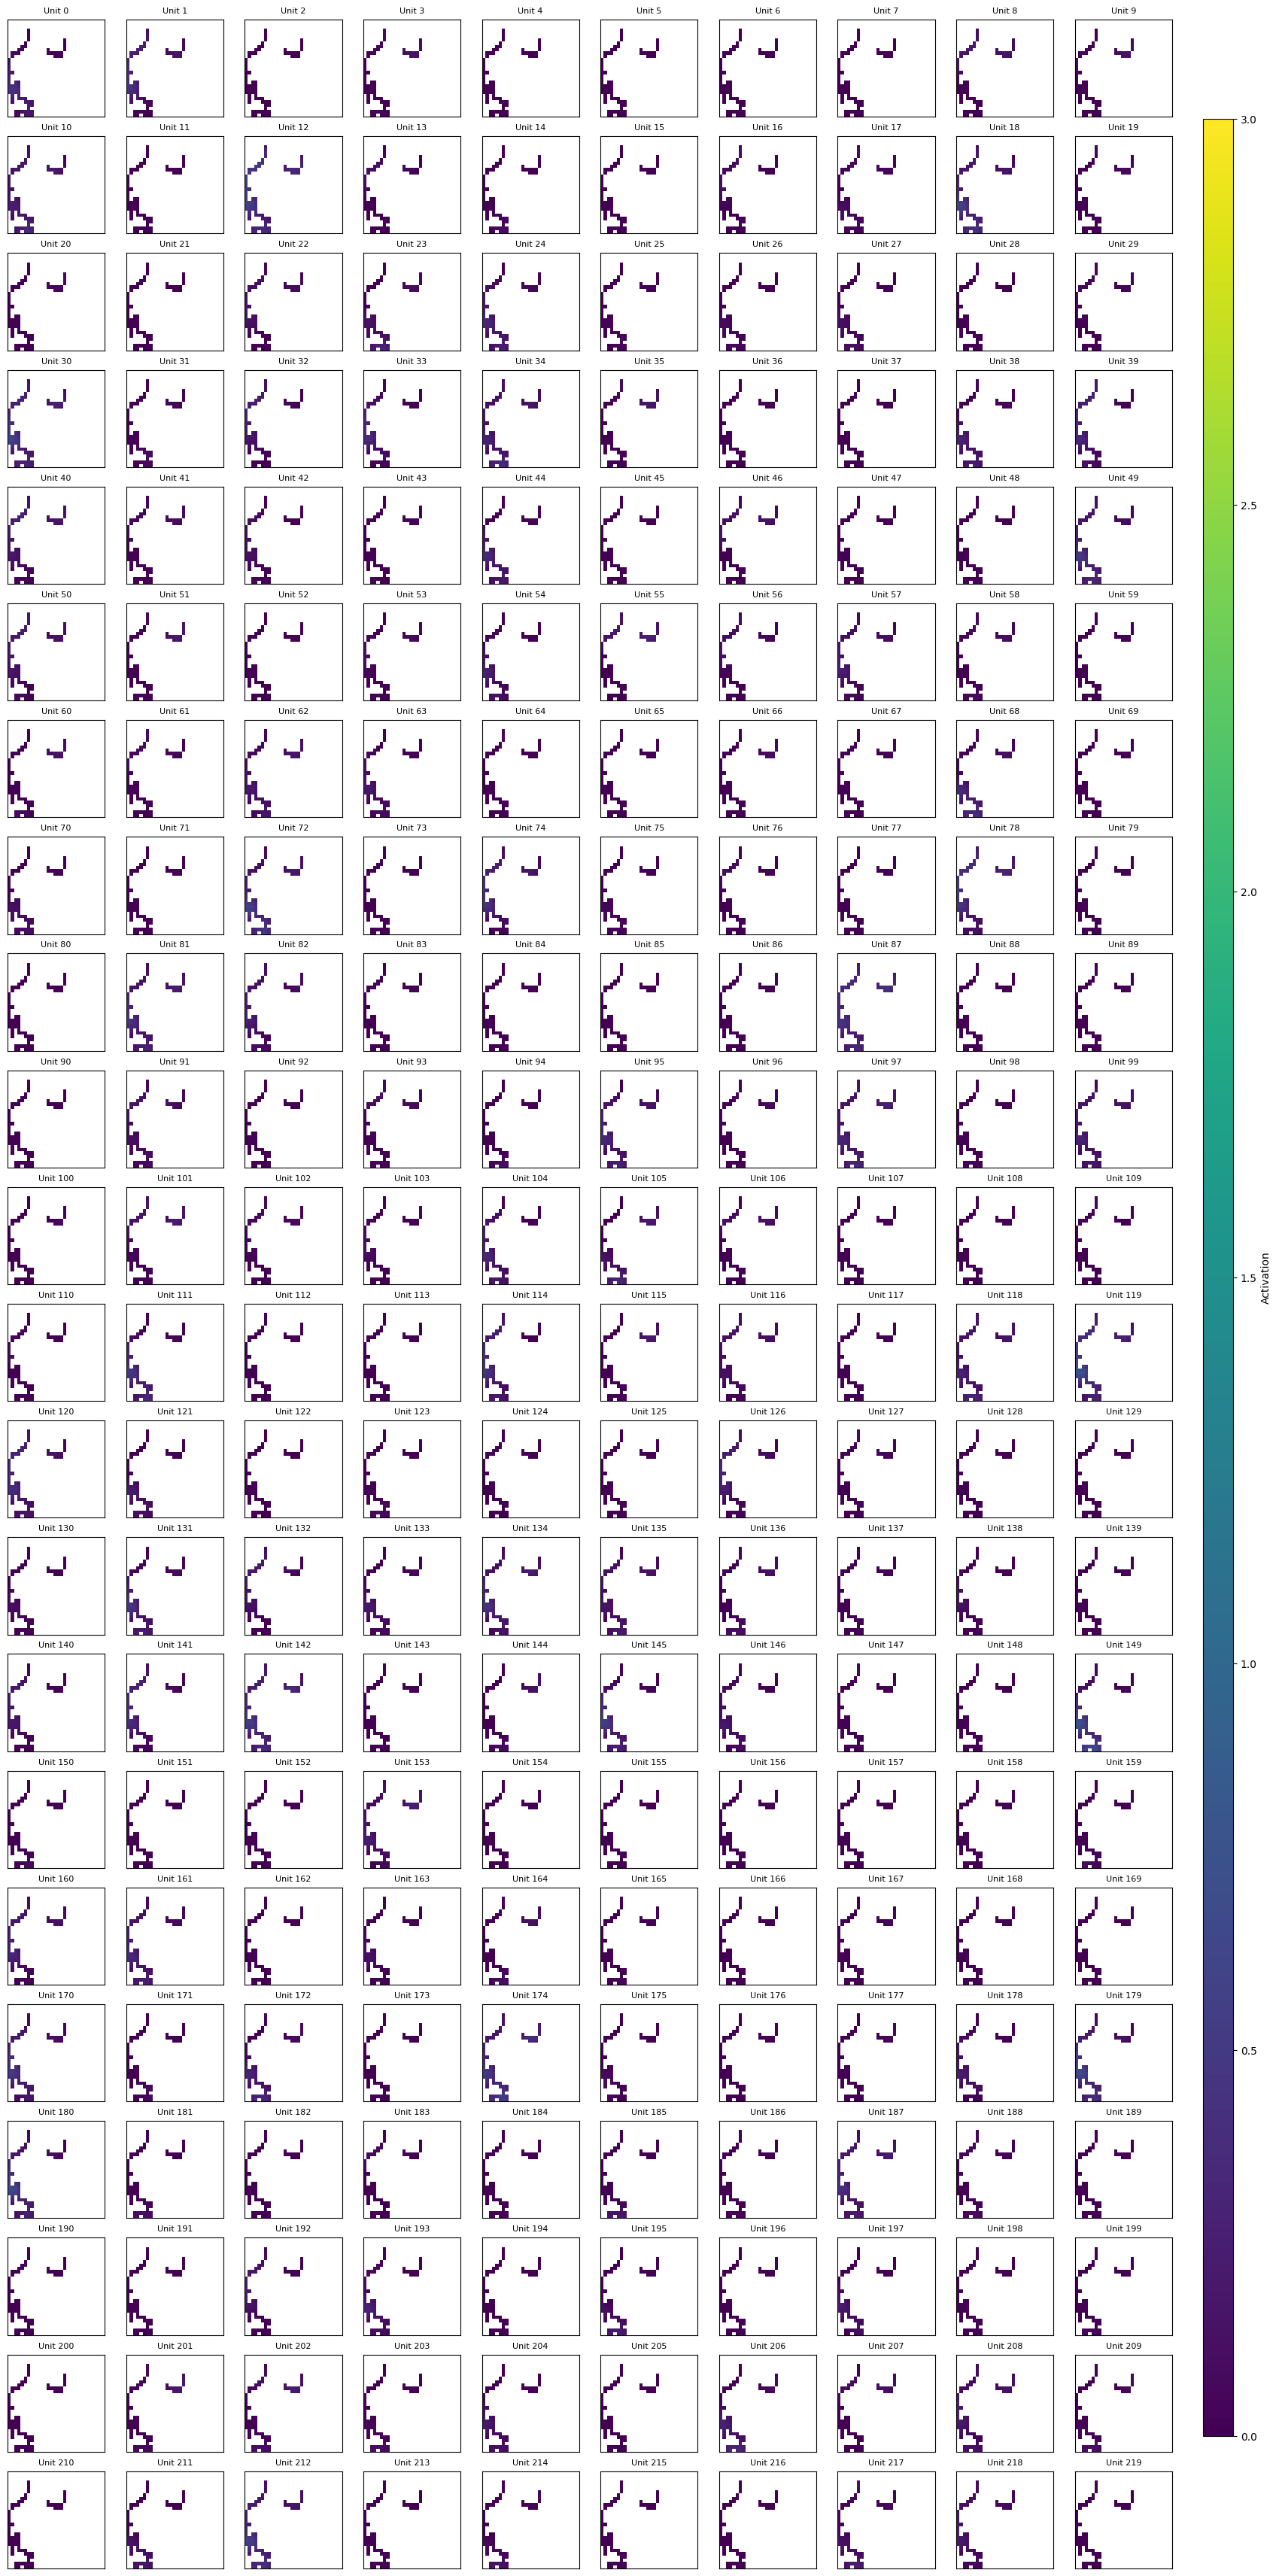

In [33]:
rate_maps, occupancy_map = compute_rate_maps_single(out_arrays=out_array, states=states, n_spatial_bins=30, filter_size=1.5)
plot_units_rate_maps(rate_maps)
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def compute_rate_maps_single(
    states,
    out_arrays,
    n_spatial_bins=15,
    filter_size=1.5,
    obstacles=None
):
    """
    Rate maps using consistent (y, x) indexing.
    Assumes environment is [0,1] x [0,1].
    """

    # =========================
    # Flatten
    # =========================
    position = np.array([s for ep in states for s in ep])
    trace    = np.array([o for ep in out_arrays for o in ep])

    n_units = trace.shape[1]
    T = trace.shape[0]

    rate_maps = np.zeros((n_units, n_spatial_bins, n_spatial_bins))
    count_map = np.zeros((n_spatial_bins, n_spatial_bins))

    # =========================
    # Bin positions (NO swapping issues)
    # =========================
    position = np.clip(position, 0.0, 1.0)

    position_binned = (position * n_spatial_bins).astype(int)
    position_binned = np.clip(position_binned, 0, n_spatial_bins - 1)

    # =========================
    # ACCUMULATION (FIXED: y, x order)
    # =========================
    for t, (x, y) in enumerate(position_binned):
        rate_maps[:, y, x] += trace[t]
        count_map[y, x] += 1

    # =========================
    # Occupancy mask
    # =========================
    nan_map = np.full_like(count_map, np.nan)
    nan_map[count_map > 0] = 1.0

    # =========================
    # Obstacles (FIXED indexing)
    # =========================
    if obstacles is not None and len(obstacles) > 0:
        bin_edges = np.linspace(0, 1, n_spatial_bins + 1)

        for obs in obstacles:
            for ix in range(n_spatial_bins):
                for iy in range(n_spatial_bins):

                    bin_x_min, bin_x_max = bin_edges[ix], bin_edges[ix + 1]
                    bin_y_min, bin_y_max = bin_edges[iy], bin_edges[iy + 1]

                    if (bin_x_min <= obs['x_max'] and bin_x_max >= obs['x_min'] and
                        bin_y_min <= obs['y_max'] and bin_y_max >= obs['y_min']):
                        nan_map[iy, ix] = np.nan

    # =========================
    # Normalize
    # =========================
    rate_maps = rate_maps / np.where(count_map > 0, count_map, 1)

    # =========================
    # Smooth
    # =========================
    if filter_size:
        rate_maps = gaussian_filter1d(rate_maps, sigma=filter_size, axis=1)
        rate_maps = gaussian_filter1d(rate_maps, sigma=filter_size, axis=2)

    # =========================
    # Apply mask
    # =========================
    for u in range(n_units):
        rate_maps[u] *= nan_map

    occupancy_map = count_map / T

    plt.scatter(position[:,0], position[:,1], s=5)
    plt.title("Trajectory")
    plt.show()

    plt.imshow(rate_maps[0], origin="lower")
    plt.title("Unit 0 rate map")
    plt.show()

    return rate_maps, occupancy_map

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_units_rate_maps(
    rate_maps,
    fill_na=False,
    n_cols=10,
    save_dir=None,
    filename=None,
    vmin=0,
    vmax=3
):
    """
    Plot rate maps using consistent (y, x) convention.
    """

    n_units = rate_maps.shape[0]
    n_rows = int(np.ceil(n_units / n_cols))

    data = rate_maps.copy()

    if fill_na:
        data = np.where(np.isnan(data), vmin, data)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 2, n_rows * 2)
    )

    axes = np.array(axes).reshape(n_rows, n_cols)

    for unit in range(n_units):
        ax = axes[unit // n_cols, unit % n_cols]

        im = ax.imshow(
            data[unit],          # ❗ NO TRANSPOSE
            origin='lower',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"Unit {unit}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide unused axes
    for i in range(n_units, n_rows * n_cols):
        axes[i // n_cols, i % n_cols].set_visible(False)

    # Colorbar
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Activation")

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(
            os.path.join(save_dir, filename),
            dpi=300,
            bbox_inches="tight"
        )

    return fig, axes